# Modelagem Supervisionada — Risco de Alfabetização nos Municípios

**Tech Challenge Fase 3 · POSTECH AI Scientist**

## Modelos abordados

- Regressão Logística
- Árvore de Decisão
- SVM (Support Vector Machine)
- Naive Bayes
- Random Forest
- Gradient Boosting

## Objetivos deste notebook

Ao final teremos:

- um alvo binário construído a partir de dado agregado, com o vazamento tratado;
- os seis modelos treinados pela **mesma** pipeline e comparados na mesma validação;
- os hiperparâmetros otimizados por `GridSearchCV` com diagnóstico de overfitting;
- a avaliação final no conjunto de teste, tocado **uma única vez**;
- a interpretação do modelo escolhido por coeficientes, *permutation importance* e SHAP.

# Contexto do Problema

O Tech Challenge pede prever se **um aluno** será considerado alfabetizado ou não.

Nenhuma fonte pública desce ao aluno — INEP, Censo Escolar, INSE e IDEB são todos agregados
municipais, sem identificador de estudante. Modelamos então o **contexto que responde por essa
criança**: o município entra como *em risco* quando **menos da metade** das suas crianças chega
alfabetizada ao fim do 2º ano.

A leitura para a pergunta original é direta: *uma criança que estuda num município sinalizado em
risco tem chance substancialmente menor de ser considerada alfabetizada*.

Com base em duas naturezas de variáveis:

- **histórico** — como a rede vinha indo (taxa e nota de 2023, IDEB de 2021);
- **atualidade** — como o município é hoje (nível socioeconômico, formação docente, esforço
  docente, tamanho de turma, ruralidade, porte e UF).

| Exigência do enunciado | Etapa |
|---|---|
| Imputação de valores faltantes | 7 |
| Encoding de variáveis categóricas | 7 |
| Tratamento de data leakage | 3 e [notebook 01](01_pipeline_medalhao.ipynb) |
| Pré-processamento integrado ao modelo | 7 |
| Treinamento e validação | 8 e 9 |
| Otimização de hiperparâmetros | 10 e 11 |
| Replicabilidade e generalização | 6, 9 e 12 |
| Interpretabilidade (Feature Importance / SHAP) | 16 |

## Etapa 1 — Importando as bibliotecas

In [1]:
# ============================================================
# 1. IMPORTANDO AS BIBLIOTECAS
# ============================================================

import sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Divisão, validação e otimização
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_validate,
                                     train_test_split, validation_curve)

# Métricas
from sklearn.metrics import (classification_report, precision_recall_curve,
                             roc_curve, roc_auc_score, average_precision_score)

# Interpretabilidade
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

# Módulos do projeto — a lógica mora em src/, o notebook orquestra
from src.modeling import (ATUALIDADE, HISTORICO, LIMIAR_RISCO, construir_pipeline,
                          modelos_candidatos, montar_painel, nomes_das_features,
                          resumir_rotulo, rotular_risco)
from src.evaluation import avaliar, curva_calibracao, limiar_por_recall, matriz_confusao
from src.visualization import (EIXO, MUDO, NEGATIVO, SERIE, TINTA, TINTA_2,
                               aplicar_estilo, limpar, num, salvar)

warnings.filterwarnings("ignore")
aplicar_estilo()
pd.set_option("display.width", 170)

IMAGENS = RAIZ / "images"; IMAGENS.mkdir(exist_ok=True)
SEMENTE = 42

## Etapa 2 — Carregando o painel de modelagem

O painel junta a **atualidade** do ciclo de 2024 com o **histórico** de 2023, uma linha por
município.

In [2]:
# ============================================================
# 2. CARREGANDO O PAINEL DE MODELAGEM
# ============================================================

painel = montar_painel()
painel.head()

,id_municipio,sigla_uf,regiao,taxa_alfabetizacao,afd_ai_grupo_1,afd_ai_grupo_2,afd_ai_grupo_3,afd_ai_grupo_4,afd_ai_grupo_5,atu_creche,...,inse_pc_nivel_8,proporcao_rural,ideb_2021,nota_portugues_2021,nota_matematica_2021,indicador_rendimento_2021,taxa_aprovacao_2021,ano,taxa_2023,media_portugues_2023
0,1100015,RO,Norte,67.79,69.3,0.0,0.2,0.0,30.5,14.8,...,1.25,0.1459,4.8,181.93,191.69,0.979422,97.8,2024,64.55,758.33
1,1100023,RO,Norte,65.62,83.6,1.9,10.2,0.4,3.9,18.7,...,0.41,0.2165,4.5,189.83,200.35,0.866519,87.2,2024,62.30,757.10
2,1100031,RO,Norte,75.88,100.0,0.0,0.0,0.0,0.0,36.5,...,2.12,0.0000,5.1,190.63,207.16,0.939656,94.9,2024,69.10,767.88
3,1100049,RO,Norte,65.81,86.7,2.1,5.2,0.7,5.3,14.7,...,1.01,0.4014,5.6,202.35,208.39,0.998998,99.9,2024,62.51,755.56
4,1100056,RO,Norte,66.81,92.3,0.0,6.4,0.0,1.3,14.8,...,0.51,0.0000,5.5,199.81,206.88,1.000000,100.0,2024,58.53,746.46


In [3]:
print(f"Tamanho do painel (linhas, colunas): {painel.shape}")
print(f"Municípios: {painel['id_municipio'].nunique()} | UFs: {painel['sigla_uf'].nunique()}")

Tamanho do painel (linhas, colunas): (5396, 40)
Municípios: 5396 | UFs: 24


In [4]:
# Conferência das variáveis de histórico — as que vêm do ciclo anterior
painel[HISTORICO].describe().round(2)

,taxa_2023,media_portugues_2023,ideb_2021,taxa_aprovacao_2021
count,5396.00,5396.00,4697.00,5145.00
mean,60.20,750.37,5.54,97.44
std,19.77,24.32,0.84,3.91
min,4.35,673.30,3.00,70.70
25%,46.47,734.68,4.90,96.60
50%,60.64,749.14,5.60,99.20
75%,74.94,763.52,6.10,100.00
max,100.00,868.46,9.50,100.00


São **5.396 municípios**: os de 2024 que também aparecem em 2023. Os 52 restantes ficam de fora
por não terem histórico (os do Acre só existem em 2024).

## Etapa 3 — Definindo a variável alvo e tratando o data leakage

**`em_risco = taxa_alfabetizacao < 50%`.** Corte absoluto e interpretável sem contexto
estatístico. Duas alternativas foram descartadas: a **meta pactuada**, que é calculada a partir
da taxa de 2023 do próprio município (circular), e a **média nacional**, que é relativa —
metade do país estaria em risco por construção.

**Sobre o vazamento:** 23 colunas do arquivo do INEP são a mesma medição que gerou o alvo e
foram removidas na camada de dados ([notebook 01](01_pipeline_medalhao.ipynb) §5). O critério não
é a força da correlação, e sim: *esta informação estaria disponível no momento da predição?* Por
isso `media_portugues` de **2024** sai e a de **2023** fica — **vazamento é contemporâneo, não
histórico**.

In [5]:
# ============================================================
# 3. DEFININDO A VARIÁVEL ALVO
# ============================================================

painel, y = rotular_risco(painel, limiar=LIMIAR_RISCO)
resumir_rotulo(painel, y)

,medida,valor
0,municípios,5396.00
1,em risco (taxa < 50%),1464.00
2,fora de risco,3932.00
3,prevalência do risco (%),27.13
4,acurácia do baseline (%),72.87


A classe de risco é a **minoritária** (27,1%). Isso já decide as métricas: um modelo que responda
"fora de risco" para todo mundo acerta **72,9%** sem servir para nada. A acurácia será sempre
reportada ao lado desse baseline.

## Etapa 4 — Visualização dos dados e do alvo

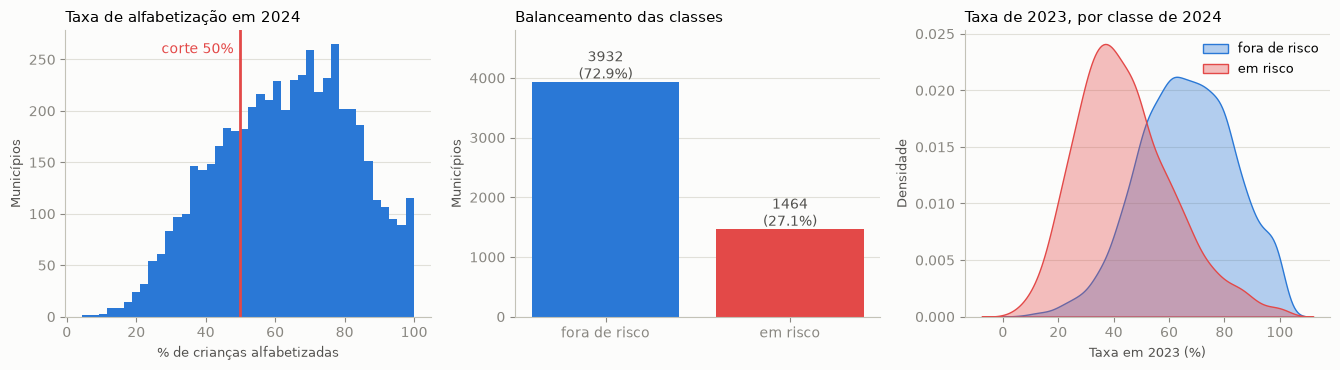

In [6]:
# ============================================================
# 4. VISUALIZAÇÃO DOS DADOS
# ============================================================

fig, eixos = plt.subplots(1, 3, figsize=(13.5, 3.8))

# 4.1 — onde o corte cai na distribuição da taxa
eixos[0].hist(painel["taxa_alfabetizacao"], bins=40, color=SERIE[0])
eixos[0].axvline(LIMIAR_RISCO, color=NEGATIVO, linewidth=2)
eixos[0].text(LIMIAR_RISCO - 2, eixos[0].get_ylim()[1] * 0.92, "corte 50%",
              ha="right", color=NEGATIVO, fontsize=10)
eixos[0].set_title("Taxa de alfabetização em 2024", loc="left")
eixos[0].set_xlabel("% de crianças alfabetizadas"); eixos[0].set_ylabel("Municípios")

# 4.2 — balanceamento das classes
contagem = pd.Series(y).value_counts().sort_index()
eixos[1].bar(["fora de risco", "em risco"], contagem.values, color=[SERIE[0], NEGATIVO])
for i, valor in enumerate(contagem.values):
    eixos[1].text(i, valor + 60, f"{valor}\n({valor / len(y) * 100:.1f}%)",
                  ha="center", fontsize=10, color=TINTA_2)
eixos[1].set_ylim(0, contagem.max() * 1.22)
eixos[1].set_title("Balanceamento das classes", loc="left"); eixos[1].set_ylabel("Municípios")

# 4.3 — a variável de histórico separa as classes?
for rotulo, cor, valor in [("fora de risco", SERIE[0], 0), ("em risco", NEGATIVO, 1)]:
    sns.kdeplot(painel.loc[y == valor, "taxa_2023"], ax=eixos[2],
                color=cor, fill=True, alpha=0.35, label=rotulo)
eixos[2].set_title("Taxa de 2023, por classe de 2024", loc="left")
eixos[2].set_xlabel("Taxa em 2023 (%)"); eixos[2].set_ylabel("Densidade")
eixos[2].legend(fontsize=9)

for eixo in eixos:
    limpar(eixo)
fig.tight_layout(); salvar(fig, "03_alvo", IMAGENS); plt.show()

O corte de 50% cai numa **região densa** da distribuição — não isola uma cauda residual. E o
terceiro painel já antecipa o resultado da Etapa 9: a taxa do ano anterior separa muito bem as
duas classes.

## Etapa 5 — Definindo X e y

In [7]:
# ============================================================
# 5. DEFININDO X E y
# ============================================================

X = painel   # a pipeline seleciona as colunas pelo ColumnTransformer

print(f"Histórico  ({len(HISTORICO):2d}): {HISTORICO}")
print(f"Atualidade ({len(ATUALIDADE):2d}): {ATUALIDADE[:6]} ...")
print(f"\ny: {y.shape} | classe positiva = em risco")

Histórico  ( 4): ['taxa_2023', 'media_portugues_2023', 'ideb_2021', 'taxa_aprovacao_2021']
Atualidade (24): ['afd_ai_grupo_1', 'afd_ai_grupo_2', 'afd_ai_grupo_3', 'afd_ai_grupo_4', 'ied_ai_nivel_2', 'ied_ai_nivel_3'] ...

y: (5396,) | classe positiva = em risco


## Etapa 6 — Divisão em treino e teste

`train_test_split` **estratificado**: com a classe de risco em 27%, um sorteio simples poderia
produzir partições com prevalências diferentes e as métricas ficariam instáveis por acidente.

O conjunto de teste é reservado agora e **só será tocado na Etapa 12**.

In [8]:
# ============================================================
# 6. DIVISÃO TREINO E TESTE
# ============================================================

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEMENTE)

print(f"Treino: {X_treino.shape[0]} municípios ({y_treino.mean():.1%} em risco)")
print(f"Teste : {X_teste.shape[0]} municípios ({y_teste.mean():.1%} em risco)")

Treino: 4047 municípios (27.1% em risco)
Teste : 1349 municípios (27.1% em risco)


## Etapa 7 — Pré-processamento integrado ao Pipeline

O enunciado exige o pré-processamento **dentro** do modelo, e a razão é prática: assim a mediana
da imputação, a média e o desvio da padronização e as categorias do encoder são calculadas
**apenas com o fold de treino**. Padronizar antes de separar os folds usaria estatística do
conjunto de validação — vazamento silencioso, que não gera erro nenhum e infla a métrica.

| Ramo | Tratamento | Por quê |
|---|---|---|
| Numéricas | mediana → `StandardScaler` | escalas de 3 a 80.160 contra 4 a 6; sem padronizar, a penalidade L2 puniria as variáveis pequenas |
| IDEB e aprovação | mediana **com `add_indicator=True`** | 13,3% de ausência concentrada em municípios pequenos: **a ausência é sinal** |
| Categóricas | moda → `OneHotEncoder(drop="first")` | *dummy encoding*, descartando uma categoria para evitar multicolinearidade |

In [9]:
# ============================================================
# 7. PRÉ-PROCESSAMENTO DENTRO DO PIPELINE
# ============================================================

pipeline_base = construir_pipeline()
pipeline_base

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('ausencia_informativa', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

> **Normalização — quem precisa e quem não precisa** (aula de classificação): Árvores e Naive
> Bayes não precisam; Regressão Logística e SVM precisam. Como todos passam pelo **mesmo**
> `Pipeline`, padronizar não prejudica os primeiros e garante os segundos — e mantém a comparação
> justa.

## Etapa 8 — Treinando os seis modelos

Os quatro da aula de classificação supervisionada mais os dois ensembles da aula de otimização.
Todos passam pelo **mesmo** `Pipeline` — só o estimador muda, e é isso que torna a comparação
justa.

| # | Modelo | Ideia principal | Precisa de padronização? |
|---|---|---|---|
| 1 | **Regressão Logística** | estima **probabilidades** pela função sigmoide; coeficientes em *odds ratio* | sim |
| 2 | **Árvore de Decisão** | cria **regras hierárquicas** | não |
| 3 | **SVM (RBF)** | procura a **melhor fronteira** de separação | sim |
| 4 | **Naive Bayes** | **probabilidade condicional**, assumindo independência entre as variáveis | não |
| 5 | **Random Forest** | *bagging*: muitas árvores em amostras diferentes, decisão por maioria | não |
| 6 | **Gradient Boosting** | *boosting*: árvores em sequência, cada uma corrigindo o erro da anterior | não |

Como todos passam pelo mesmo pré-processamento, padronizar não prejudica os que não precisam e
garante os que precisam.

> **Atenção ao Naive Bayes.** A base tem três blocos composicionais (AFD, IED e níveis do INSE,
> que somam 100% cada), então a premissa de independência é violada por construção. A Etapa 9
> mostra a consequência.

In [10]:
# ============================================================
# 8. TREINANDO OS SEIS MODELOS
# ============================================================

modelos = modelos_candidatos(SEMENTE)
ajustados = {}

for nome, estimador in modelos.items():
    pipeline = construir_pipeline(estimador=estimador)
    pipeline.fit(X_treino, y_treino)
    ajustados[nome] = pipeline
    print(f"{nome:32s} acurácia no teste: {pipeline.score(X_teste, y_teste):.4f}")

Baseline (classe majoritária)    acurácia no teste: 0.7287
Regressão Logística              acurácia no teste: 0.8436
Árvore de Decisão                acurácia no teste: 0.8258


SVM (RBF)                        acurácia no teste: 0.8414
Naive Bayes                      acurácia no teste: 0.6798


Random Forest                    acurácia no teste: 0.8532


Gradient Boosting                acurácia no teste: 0.8391


Estas acurácias vieram de **uma** partição e do limiar padrão de 0,5 — pouco confiável para
escolher modelo, e ainda por cima próximas do baseline de 72,9%. A Etapa 9 refaz a comparação com
validação cruzada e métricas que não dependem do limiar.

Antes disso, vale olhar por dentro do modelo mais fácil de explicar.

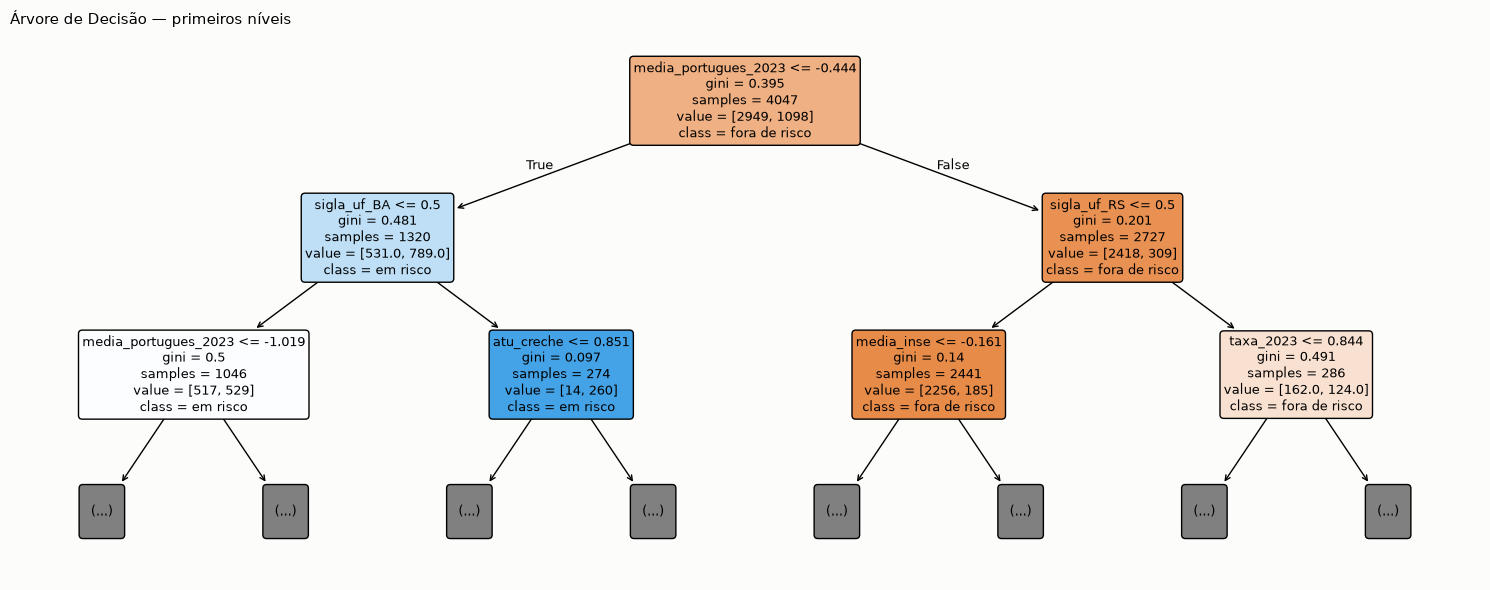

In [11]:
# ============================================================
# 8.1 — VISUALIZANDO A ÁRVORE DE DECISÃO (3 primeiros níveis)
# ============================================================

arvore = ajustados["Árvore de Decisão"]

fig, eixo = plt.subplots(figsize=(15, 6))
plot_tree(arvore.named_steps["modelo"],
          feature_names=nomes_das_features(arvore),
          class_names=["fora de risco", "em risco"],
          max_depth=2, filled=True, rounded=True, fontsize=9, ax=eixo)
eixo.set_title("Árvore de Decisão — primeiros níveis", loc="left")
fig.tight_layout(); salvar(fig, "03_arvore", IMAGENS); plt.show()

A árvore redescobre sozinha os dois achados do projeto. A **primeira divisão** é a nota de
Português de **2023** — o histórico da rede é o preditor mais forte da base. E o **segundo nível**
já usa dummies de UF (Bahia de um lado, Rio Grande do Sul do outro): o território aparece logo
depois do histórico, antes de qualquer variável socioeconômica.

## Etapa 9 — Comparação dos modelos com validação cruzada estratificada

As acurácias acima vieram de **uma** partição e do limiar padrão de 0,5 — pouco confiável para
escolher modelo. A comparação séria usa **`StratifiedKFold` de 5 folds sobre o treino**, com
`return_train_score=True` para diagnosticar overfitting, e prioriza métricas que não dependem do
limiar.

In [12]:
# ============================================================
# 9. COMPARAÇÃO DOS MODELOS (5-FOLD ESTRATIFICADO)
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
METRICAS = ["roc_auc", "average_precision", "recall", "precision", "accuracy"]

linhas = []
for nome, estimador in modelos.items():
    inicio = time.perf_counter()
    r = cross_validate(construir_pipeline(estimador=estimador), X_treino, y_treino,
                       cv=skf, scoring=METRICAS, return_train_score=True, n_jobs=-1)
    linhas.append({
        "Modelo": nome,
        "ROC-AUC": r["test_roc_auc"].mean(),
        "PR-AUC": r["test_average_precision"].mean(),
        "Recall (risco)": r["test_recall"].mean(),
        "Precisão (risco)": r["test_precision"].mean(),
        "Acurácia": r["test_accuracy"].mean(),
        "Gap treino-val.": r["train_roc_auc"].mean() - r["test_roc_auc"].mean(),
        "Tempo (s)": time.perf_counter() - inicio,
    })

resultados = pd.DataFrame(linhas).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
resultados.round(4)

,Modelo,ROC-AUC,PR-AUC,Recall (risco),Precisão (risco),Acurácia,Gap treino-val.,Tempo (s)
0,Gradient Boosting,0.9117,0.8129,0.6639,0.7646,0.8527,0.0607,1.6325
1,Random Forest,0.9096,0.8095,0.5847,0.7950,0.8461,0.0587,0.7122
2,Regressão Logística,0.9146,0.8093,0.6657,0.7629,0.8525,0.0084,0.8564
3,SVM (RBF),0.9010,0.7991,0.6038,0.8100,0.8540,0.0536,1.8795
4,Árvore de Decisão,0.8791,0.7410,0.5946,0.7300,0.8285,0.0388,0.8662
5,Naive Bayes,0.8656,0.6739,0.9262,0.4471,0.6659,0.0062,0.0661
6,Baseline (classe majoritária),0.5000,0.2713,0.0000,0.0000,0.7287,0.0000,3.6871


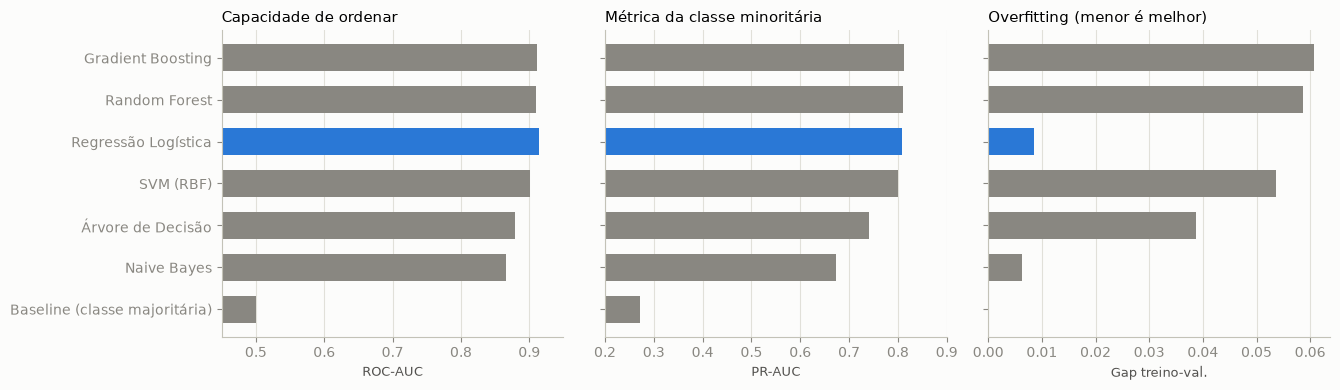

In [13]:
# ============================================================
# 9.1 — VISUALIZAÇÃO DA COMPARAÇÃO
# ============================================================

fig, eixos = plt.subplots(1, 3, figsize=(13.5, 4.0))
ordenado = resultados.sort_values("PR-AUC")
cores = [SERIE[0] if m == "Regressão Logística" else MUDO for m in ordenado["Modelo"]]

for eixo, coluna, titulo in zip(
        eixos,
        ["ROC-AUC", "PR-AUC", "Gap treino-val."],
        ["Capacidade de ordenar", "Métrica da classe minoritária", "Overfitting (menor é melhor)"]):
    eixo.barh(ordenado["Modelo"], ordenado[coluna], color=cores, height=0.65)
    eixo.set_title(titulo, loc="left"); eixo.set_xlabel(coluna)
    limpar(eixo, grade="x")

eixos[0].set_xlim(0.45, 0.95); eixos[1].set_xlim(0.2, 0.9)
for eixo in eixos[1:]:
    eixo.set_yticklabels([])
fig.tight_layout(); salvar(fig, "03_comparacao_modelos", IMAGENS); plt.show()

**Leitura — três resultados.**

1. **A Regressão Logística lidera o ROC-AUC (0,915)** e fica a 0,004 do melhor PR-AUC, com um
   **gap de overfitting sete vezes menor** que o dos ensembles (0,008 contra 0,061 e 0,059). É o
   modelo escolhido, e a escolha se sustenta em resultado medido — não em preferência.
2. **O Naive Bayes tem recall de 0,93 e precisão de 0,45**: ele dispara alarme para quase todo
   mundo. É o efeito esperado da premissa de independência aplicada a blocos composicionais, e
   confirma empiricamente o descarte que estaria só em prosa.
3. **O baseline acerta 72,9% sem prever ninguém em risco** — a prova de que acurácia sozinha não
   serve como critério aqui.

## Etapa 10 — Otimização de hiperparâmetros com GridSearchCV

Buscamos o `C` da Regressão Logística — o inverso da força da regularização L2. `scoring` é
**PR-AUC**, coerente com a classe minoritária, e `return_train_score=True` permite ver o gap.

In [14]:
# ============================================================
# 10. GRIDSEARCHCV — OTIMIZAÇÃO DE HIPERPARÂMETROS
# ============================================================

grade = {"modelo__C": [0.01, 0.1, 1.0, 10.0, 100.0]}

grid = GridSearchCV(construir_pipeline(), grade, cv=skf,
                    scoring="average_precision", n_jobs=-1,
                    return_train_score=True)
grid.fit(X_treino, y_treino)

print(f"Melhor score (PR-AUC): {grid.best_score_:.4f}")
print(f"Melhores HPs: {grid.best_params_}")
print(f"Combinações testadas: {len(grid.cv_results_['params'])}")

Melhor score (PR-AUC): 0.8093
Melhores HPs: {'modelo__C': 1.0}
Combinações testadas: 5


In [15]:
# ============================================================
# 10.1 — ANALISANDO OS RESULTADOS DO GRIDSEARCHCV
# ============================================================

cv_res = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
cv_res["gap"] = cv_res["mean_train_score"] - cv_res["mean_test_score"]

cv_res[["param_modelo__C", "mean_test_score", "std_test_score",
        "mean_train_score", "gap", "rank_test_score"]].round(4)

,param_modelo__C,mean_test_score,std_test_score,mean_train_score,gap,rank_test_score
2,1.00,0.8093,0.0257,0.8294,0.0201,1
3,10.00,0.8074,0.0244,0.8301,0.0227,2
4,100.00,0.8067,0.0240,0.8302,0.0236,3
1,0.10,0.8065,0.0296,0.8224,0.0159,4
0,0.01,0.7664,0.0391,0.7743,0.0079,5


`C = 1,0` vence, e o gap de **0,020** está muito abaixo do limiar de alerta de 0,05 usado na
aula. Note também que o desvio entre folds (0,026) é **maior** que a diferença entre `C = 0,1` e
`C = 100` — ou seja, a busca não "resolveu" nada: o modelo já não sofria de sobreajuste.

## Etapa 11 — Diagnóstico de overfitting com a Validation Curve

A curva de validação mostra treino e validação lado a lado ao longo de todo o intervalo de `C` —
é o gráfico que torna visível o que a tabela acima só insinua.

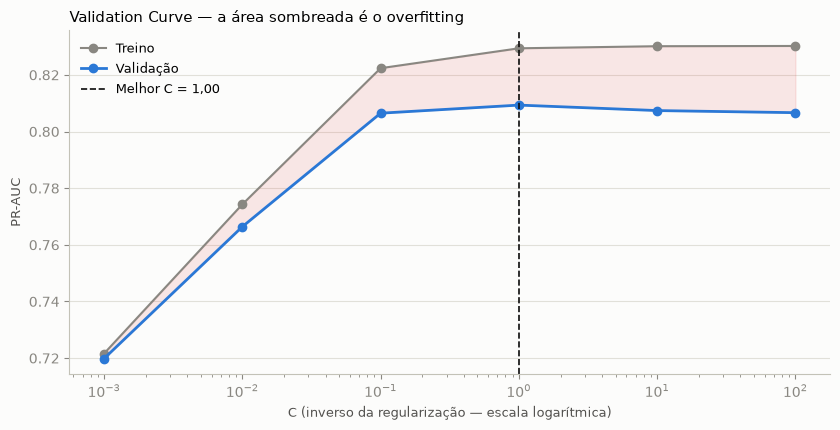

Gap em C=0,001: 0.0018  |  em C=100: 0.0236


In [16]:
# ============================================================
# 11. VALIDATION CURVE — TREINO CONTRA VALIDAÇÃO
# ============================================================

faixa_C = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
tr_scores, val_scores = validation_curve(
    construir_pipeline(), X_treino, y_treino,
    param_name="modelo__C", param_range=faixa_C,
    cv=skf, scoring="average_precision", n_jobs=-1)

treino_medio, val_medio = tr_scores.mean(axis=1), val_scores.mean(axis=1)
melhor_C = faixa_C[int(np.argmax(val_medio))]

fig, eixo = plt.subplots(figsize=(8.5, 4.4))
eixo.semilogx(faixa_C, treino_medio, marker="o", color=MUDO, label="Treino")
eixo.semilogx(faixa_C, val_medio, marker="o", color=SERIE[0], linewidth=2, label="Validação")
eixo.fill_between(faixa_C, treino_medio, val_medio, alpha=0.12, color=NEGATIVO)
eixo.axvline(melhor_C, color=TINTA, linestyle="--", linewidth=1.2,
             label=f"Melhor C = {num(melhor_C, 2)}")
eixo.set_xlabel("C (inverso da regularização — escala logarítmica)")
eixo.set_ylabel("PR-AUC")
eixo.set_title("Validation Curve — a área sombreada é o overfitting", loc="left")
eixo.legend(fontsize=9); limpar(eixo)
fig.tight_layout(); salvar(fig, "03_validation_curve", IMAGENS); plt.show()

print(f"Gap em C=0,001: {treino_medio[0] - val_medio[0]:.4f}  |  "
      f"em C=100: {treino_medio[-1] - val_medio[-1]:.4f}")

As duas curvas caminham **coladas**: o gap cresce de 0,002 a 0,024 conforme a regularização
afrouxa, mas nunca chega perto de um sobreajuste real. Com 4.047 municípios de treino para 53
features num modelo linear, a penalidade L2 é salvaguarda contra colinearidade residual, não
remédio para overfitting. Reportar isso é mais útil do que apresentar a busca como um ganho.

## Etapa 12 — Avaliação final no conjunto de teste

O modelo campeão, com os hiperparâmetros otimizados, é avaliado **uma única vez** nos 1.349
municípios reservados na Etapa 6.

In [17]:
# ============================================================
# 12. AVALIAÇÃO FINAL NO TESTE (UMA VEZ SÓ)
# ============================================================

modelo_final = grid.best_estimator_

y_pred = modelo_final.predict(X_teste)
y_proba = modelo_final.predict_proba(X_teste)[:, 1]

metricas_teste = avaliar(y_teste, y_pred, y_proba)
pd.Series(metricas_teste).to_frame("valor")

,valor
recall_risco,0.6230
precisao_risco,0.7575
f1_risco,0.6837
acuracia,0.8436
roc_auc,0.8978
pr_auc,0.7535
acuracia_baseline,0.7287


**ROC-AUC 0,898 e PR-AUC 0,754** em municípios nunca vistos — praticamente o mesmo da validação
cruzada, o que confirma que não houve sobreajuste à partição. A acurácia de 84,4% precisa ser
lida contra o baseline de **72,9%**: o ganho real é de 11,5 pontos.

## Etapa 13 — Matriz de confusão e classification report

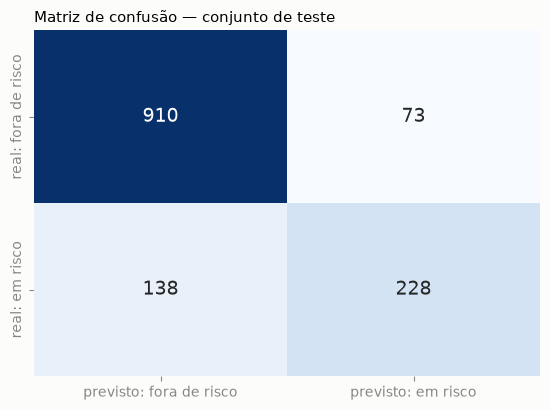

,previsto: fora de risco,previsto: em risco
real: fora de risco,910,73
real: em risco,138,228


In [18]:
# ============================================================
# 13. MATRIZ DE CONFUSÃO
# ============================================================

matriz = matriz_confusao(y_teste, y_pred)

fig, eixo = plt.subplots(figsize=(5.6, 4.2))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
            annot_kws={"fontsize": 14}, ax=eixo)
eixo.set_title("Matriz de confusão — conjunto de teste", loc="left")
fig.tight_layout(); salvar(fig, "03_matriz_confusao", IMAGENS); plt.show()

matriz

In [19]:
# ============================================================
# 13.1 — CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_teste, y_pred,
                            target_names=["fora de risco", "em risco"]))

               precision    recall  f1-score   support

fora de risco       0.87      0.93      0.90       983
     em risco       0.76      0.62      0.68       366

     accuracy                           0.84      1349
    macro avg       0.81      0.77      0.79      1349
 weighted avg       0.84      0.84      0.84      1349



**O que cada célula significa aqui.** Os 228 **verdadeiros positivos** são municípios em risco que
o modelo encontrou; os 138 **falsos negativos** são os que ele deixou passar — e este é o erro
caro, porque um município que precisa de apoio fica fora da lista. Os 73 **falsos positivos**
custam uma visita técnica desnecessária.

Recall de 0,62 e precisão de 0,76 são do limiar padrão de 0,5, que **não é o limiar de operação**
— a Etapa 15 mostra como escolhê-lo.

## Etapa 14 — Curva ROC e curva Precisão-Recall

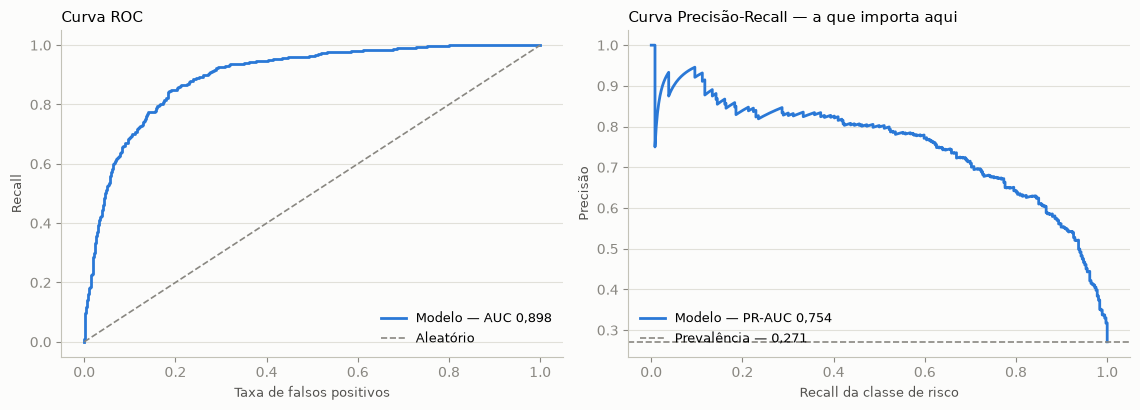

In [20]:
# ============================================================
# 14. CURVA ROC E CURVA PRECISÃO-RECALL
# ============================================================

fpr, tpr, _ = roc_curve(y_teste, y_proba)
precisao, recall, _ = precision_recall_curve(y_teste, y_proba)
auc = roc_auc_score(y_teste, y_proba)
pr_auc = average_precision_score(y_teste, y_proba)

fig, eixos = plt.subplots(1, 2, figsize=(11.5, 4.2))

eixos[0].plot(fpr, tpr, color=SERIE[0], linewidth=2, label=f"Modelo — AUC {num(auc, 3)}")
eixos[0].plot([0, 1], [0, 1], color=MUDO, linestyle="--", linewidth=1.2, label="Aleatório")
eixos[0].set_xlabel("Taxa de falsos positivos"); eixos[0].set_ylabel("Recall")
eixos[0].set_title("Curva ROC", loc="left"); eixos[0].legend(fontsize=9, loc="lower right")

eixos[1].plot(recall, precisao, color=SERIE[0], linewidth=2,
              label=f"Modelo — PR-AUC {num(pr_auc, 3)}")
eixos[1].axhline(y_teste.mean(), color=MUDO, linestyle="--", linewidth=1.2,
                 label=f"Prevalência — {num(y_teste.mean(), 3)}")
eixos[1].set_xlabel("Recall da classe de risco"); eixos[1].set_ylabel("Precisão")
eixos[1].set_title("Curva Precisão-Recall — a que importa aqui", loc="left")
eixos[1].legend(fontsize=9, loc="lower left")

for eixo in eixos:
    limpar(eixo)
fig.tight_layout(); salvar(fig, "03_roc_pr", IMAGENS); plt.show()

A curva **Precisão-Recall** é a que importa: com a classe positiva em 27%, a ROC se deixa inflar
pelos verdadeiros negativos, que são maioria. A linha tracejada da direita marca o que um modelo
aleatório entregaria (0,271); estamos bem acima dela em toda a faixa.

## Etapa 15 — Calibração e escolha do limiar de decisão

O corte de 0,5 é convenção do software, não decisão de política. Antes de escolhê-lo, é preciso
verificar se a probabilidade é **confiável**.

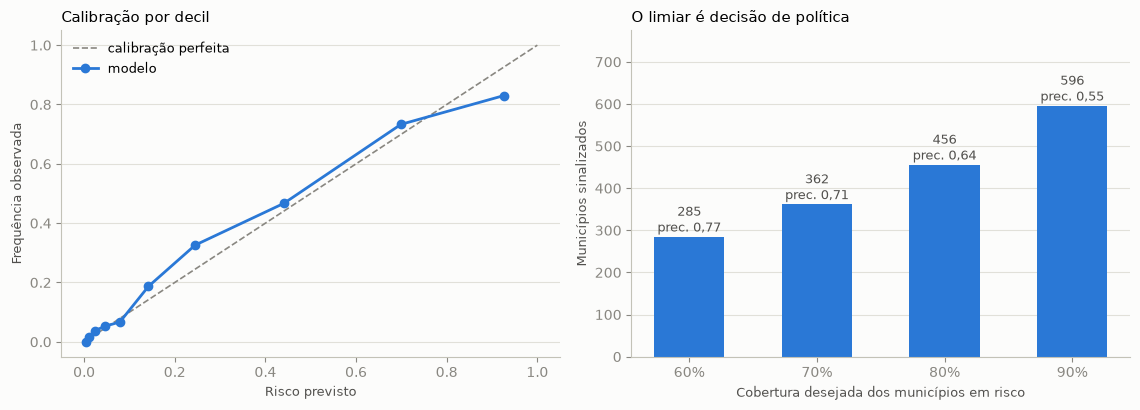

Desvio médio absoluto de calibração: 0,0323


,recall_desejado,limiar,municipios_sinalizados,recall_risco,precisao_risco
0,0.6,0.542,285,0.601,0.772
1,0.7,0.393,362,0.702,0.710
2,0.8,0.258,456,0.800,0.642
3,0.9,0.146,596,0.902,0.554


In [21]:
# ============================================================
# 15. CALIBRAÇÃO
# ============================================================

calibracao = curva_calibracao(y_teste, y_proba)

fig, eixos = plt.subplots(1, 2, figsize=(11.5, 4.2))

eixos[0].plot([0, 1], [0, 1], color=MUDO, linestyle="--", linewidth=1.2,
              label="calibração perfeita")
eixos[0].plot(calibracao["previsto"], calibracao["observado"], marker="o",
              color=SERIE[0], linewidth=2, label="modelo")
eixos[0].set_xlabel("Risco previsto"); eixos[0].set_ylabel("Frequência observada")
eixos[0].set_title("Calibração por decil", loc="left"); eixos[0].legend(fontsize=9)

# Quantos municípios entram conforme a cobertura desejada
cobertura = pd.DataFrame([limiar_por_recall(y_teste, y_proba, r) for r in (0.6, 0.7, 0.8, 0.9)])
eixos[1].bar([f"{int(r * 100)}%" for r in cobertura["recall_desejado"]],
             cobertura["municipios_sinalizados"], color=SERIE[0], width=0.55)
for i, (n, p) in enumerate(zip(cobertura["municipios_sinalizados"], cobertura["precisao_risco"])):
    eixos[1].text(i, n + 12, f"{n}\nprec. {num(p, 2)}", ha="center", fontsize=9.5, color=TINTA_2)
eixos[1].set_ylim(0, cobertura["municipios_sinalizados"].max() * 1.3)
eixos[1].set_xlabel("Cobertura desejada dos municípios em risco")
eixos[1].set_ylabel("Municípios sinalizados")
eixos[1].set_title("O limiar é decisão de política", loc="left")

for eixo in eixos:
    limpar(eixo)
fig.tight_layout(); salvar(fig, "03_calibracao", IMAGENS); plt.show()

desvio = (calibracao["previsto"] - calibracao["observado"]).abs().mean()
print(f"Desvio médio absoluto de calibração: {num(desvio, 4)}")
cobertura[["recall_desejado", "limiar", "municipios_sinalizados",
           "recall_risco", "precisao_risco"]].round(3)

Os pontos ficam sobre a diagonal — a saída pode ser lida como **probabilidade**, não só como
ordenação. E o painel da direita põe preço na decisão: cobrir 80% dos municípios em risco custa
precisão (0,64 contra 0,77 em 60%), ou seja, mais visitas técnicas a quem não precisava. **O
modelo não decide; ele mostra o câmbio.**

## Etapa 16 — Interpretabilidade: coeficientes, permutation importance e SHAP

Três lentes, porque respondem a perguntas diferentes: o **coeficiente** dá o efeito de cada
variável mantidas as demais constantes; a **permutation importance** mede quanto o modelo perde
sem ela; o **SHAP** mede a contribuição em cada predição concreta.

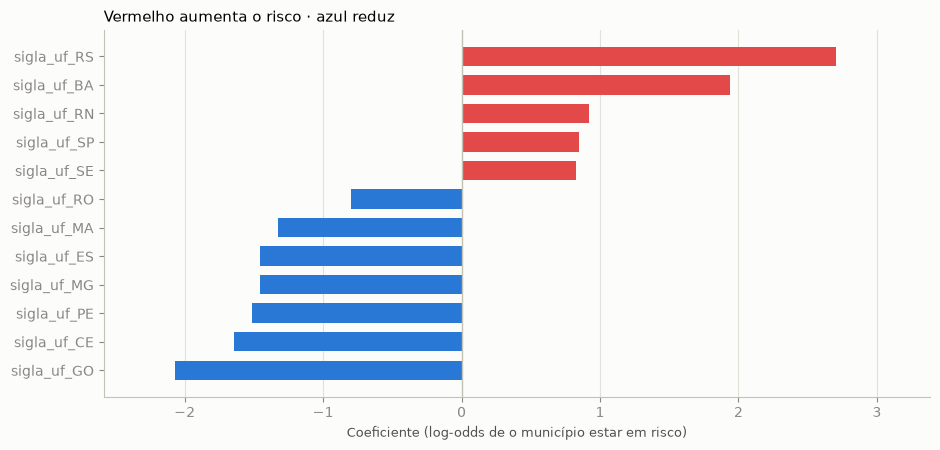

,coeficiente,odds_ratio_risco
sigla_uf_RS,2.707,14.979
sigla_uf_GO,-2.068,0.126
sigla_uf_BA,1.941,6.964
sigla_uf_CE,-1.641,0.194
sigla_uf_PE,-1.511,0.221
sigla_uf_MG,-1.457,0.233
sigla_uf_ES,-1.453,0.234
sigla_uf_MA,-1.328,0.265
sigla_uf_RN,0.920,2.510
sigla_uf_SP,0.848,2.335


In [22]:
# ============================================================
# 16. INTERPRETABILIDADE — 16.1 COEFICIENTES (ODDS RATIO)
# ============================================================

modelo_publicado = construir_pipeline(C=grid.best_params_["modelo__C"]).fit(X, y)

coeficientes = pd.DataFrame(
    {"coeficiente": modelo_publicado.named_steps["modelo"].coef_[0]},
    index=nomes_das_features(modelo_publicado))
coeficientes["odds_ratio_risco"] = np.exp(coeficientes["coeficiente"])

principais = coeficientes.reindex(
    coeficientes["coeficiente"].abs().sort_values(ascending=False).index).head(12)

ordenado = principais.sort_values("coeficiente")
fig, eixo = plt.subplots(figsize=(9.5, 4.6))
eixo.barh(ordenado.index, ordenado["coeficiente"],
          color=[SERIE[0] if v < 0 else NEGATIVO for v in ordenado["coeficiente"]], height=0.68)
eixo.axvline(0, color=EIXO, linewidth=1)
menor, maior = ordenado["coeficiente"].min(), ordenado["coeficiente"].max()
eixo.set_xlim(menor * 1.25, maior * 1.25)
eixo.set_xlabel("Coeficiente (log-odds de o município estar em risco)")
eixo.set_title("Vermelho aumenta o risco · azul reduz", loc="left")
limpar(eixo, grade="x")
fig.tight_layout(); salvar(fig, "03_coeficientes", IMAGENS); plt.show()

principais.round(3)

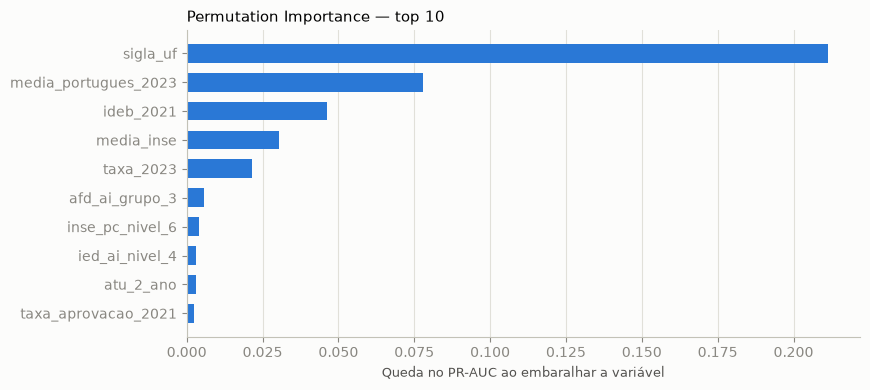

,queda_no_pr_auc
sigla_uf,0.2113
media_portugues_2023,0.0779
ideb_2021,0.0462
media_inse,0.0305
taxa_2023,0.0214
afd_ai_grupo_3,0.0056
inse_pc_nivel_6,0.0040
ied_ai_nivel_4,0.0031
atu_2_ano,0.0031
taxa_aprovacao_2021,0.0023


In [23]:
# ============================================================
# 16.2 — PERMUTATION IMPORTANCE
# ============================================================

resultado_pi = permutation_importance(
    modelo_final, X_teste, y_teste, n_repeats=10,
    random_state=SEMENTE, scoring="average_precision", n_jobs=-1)

importancia = (pd.Series(resultado_pi.importances_mean, index=X_teste.columns)
               .sort_values(ascending=False).head(10))

fig, eixo = plt.subplots(figsize=(8.8, 4.0))
eixo.barh(importancia.index[::-1], importancia.values[::-1], color=SERIE[0], height=0.65)
eixo.set_xlabel("Queda no PR-AUC ao embaralhar a variável")
eixo.set_title("Permutation Importance — top 10", loc="left")
limpar(eixo, grade="x")
fig.tight_layout(); salvar(fig, "03_permutation", IMAGENS); plt.show()

importancia.round(4).to_frame("queda_no_pr_auc")

Background dataset has 5396 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5396 when initializing the masker.


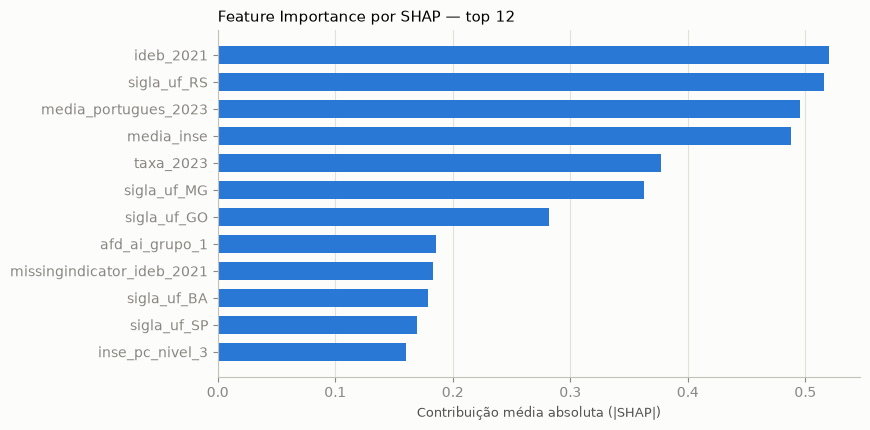

In [24]:
# ============================================================
# 16.3 — SHAP (versão executiva: bar plot da média absoluta)
# ============================================================

import shap

matriz_features = modelo_publicado.named_steps["preprocessamento"].transform(painel)
nomes = nomes_das_features(modelo_publicado)
valores_shap = pd.DataFrame(
    shap.LinearExplainer(modelo_publicado.named_steps["modelo"],
                         matriz_features).shap_values(matriz_features),
    columns=nomes)

media_shap = valores_shap.abs().mean().sort_values(ascending=False).head(12)

fig, eixo = plt.subplots(figsize=(8.8, 4.4))
eixo.barh(media_shap.index[::-1], media_shap.values[::-1], color=SERIE[0], height=0.68)
eixo.set_xlabel("Contribuição média absoluta (|SHAP|)")
eixo.set_title("Feature Importance por SHAP — top 12", loc="left")
limpar(eixo, grade="x")
fig.tight_layout(); salvar(fig, "03_shap", IMAGENS); plt.show()

**As três lentes convergem no mesmo lugar.** Embaralhar `sigla_uf` derruba o PR-AUC em **0,211** —
quase três vezes a segunda colocada (`media_portugues_2023`, 0,078) e sete vezes o nível
socioeconômico (0,031). Nos coeficientes, as dummies de UF ocupam as primeiras posições.

**O achado central do projeto.** Depois de controlar o histórico da rede, o nível socioeconômico,
a formação docente, o tamanho das turmas, a ruralidade e o porte, **o estado continua sendo o
maior efeito do modelo**. Ceará (*odds ratio* 0,19) e Bahia (6,96) são vizinhos, da mesma região,
com condições socioeconômicas próximas — e aparecem em polos opostos. O que separa os municípios
brasileiros não é principalmente a renda das famílias: é a **política pública** que cada estado
executa.

O Rio Grande do Sul aparece no polo de maior risco (*odds ratio* 14,98) por outro motivo: as
enchentes de 2024, um choque conjuntural que o modelo lê como se fosse estrutura. Está declarado
nas limitações.

## Etapa 17 — Resumo final

| Modelo | Ideia principal | ROC-AUC | Gap treino-val. |
|---|---|---:|---:|
| **Regressão Logística** | probabilidade pela sigmoide | **0,915** | **0,008** |
| Gradient Boosting | árvores em sequência corrigindo o erro | 0,912 | 0,061 |
| Random Forest | muitas árvores, decisão por maioria | 0,910 | 0,059 |
| SVM (RBF) | melhor fronteira de separação | 0,901 | 0,054 |
| Árvore de Decisão | regras hierárquicas | 0,879 | 0,039 |
| Naive Bayes | probabilidades condicionais independentes | 0,866 | 0,006 |
| Baseline | responde sempre a classe majoritária | 0,500 | 0,000 |

**Modelo escolhido: Regressão Logística com `C = 1,0`.** Lidera o ROC-AUC, empata no PR-AUC
dentro do desvio entre folds, sobreajusta sete vezes menos que os ensembles, entrega
probabilidade calibrada e é a única que responde *por quê* em unidades que um gestor entende.

**Desempenho no teste:** ROC-AUC 0,898 · PR-AUC 0,754 · recall 0,623 · precisão 0,758 ·
acurácia 0,844 contra baseline de 0,729.

### Limitações

1. **Falácia ecológica** — o modelo descreve o município, não uma criança específica: duas
   crianças do mesmo lugar recebem a mesma predição.
2. **Sem variáveis de política educacional** — o maior efeito do modelo (a UF) é justamente o que
   ele **não consegue explicar**.
3. **O ciclo de 2024 contém o choque do RS** — o risco previsto para o estado é pessimista demais.
4. **25 das 27 UFs** — o DF não tem rede municipal e Roraima está ausente da fonte.
5. **Associação, não causalidade.** Nenhuma intervenção se justifica só por estes coeficientes.

**Próximo passo:** [04 — aplicação estratégica](04_aplicacao_estrategica.ipynb), onde este mesmo
modelo responde às cinco perguntas de negócio do enunciado.